In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("yellow_tripdata_2016-01.csv")

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,1,N,-73.981842,40.732407,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8
1,2,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,1,N,-73.944473,40.716679,1,18.0,0.5,0.5,0.0,0.0,0.3,19.3
2,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,1,N,-73.950272,40.788925,1,33.0,0.5,0.5,0.0,0.0,0.3,34.3
3,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,1,N,-73.962242,40.657333,2,16.5,0.0,0.5,0.0,0.0,0.3,17.3
4,2,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,1,N,-73.977264,40.758514,2,8.0,0.0,0.5,0.0,0.0,0.3,8.8


In [4]:
df.shape

(10906858, 19)

In [5]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'payment_type', 'fare_amount',
       'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10906858 entries, 0 to 10906857
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RatecodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.5+ GB


In [7]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns

In [10]:
imputer = SimpleImputer(strategy='median')

In [11]:
df['VendorID'] = df['VendorID'].astype('int8')

df['passenger_count'] = df['passenger_count'].astype('int8')

df['RatecodeID'] = df['RatecodeID'].astype('int8')

df['payment_type'] = df['payment_type'].astype('int8')


In [12]:
float_columns = [
    'trip_distance',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount'
]

In [13]:
for col in float_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce',
        downcast='float'
    )

In [14]:

for col in float_columns:

    median_value = df[col].median()

    df[col] = df[col].fillna(median_value)

In [15]:
df = df[df['trip_distance'] > 0]

df = df[df['fare_amount'] > 0]

df = df[df['passenger_count'] > 0]

In [16]:
df.shape

(10837367, 19)

In [17]:
df['tpep_pickup_datetime'] = pd.to_datetime(
    df['tpep_pickup_datetime'],
    errors='coerce'
)

In [18]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

In [19]:
df.dropna(inplace=True)

In [20]:
df['payment_type'].value_counts()

payment_type
1    7156324
2    3642482
3      28109
4      10451
5          1
Name: count, dtype: int64

In [21]:
df = df[df['payment_type'].isin([1, 2])]

In [22]:
df['high_fare'] = np.where(
    df['fare_amount'] > 20,
    1,
    0
)

In [23]:
df['high_fare'].value_counts()

high_fare
0    9399126
1    1399680
Name: count, dtype: int64

In [24]:
features = [
    'passenger_count',
    'trip_distance',
    'pickup_hour',
    'pickup_day',
    'pickup_month'
]

In [25]:
X = df[features]

y = df['high_fare']

In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (8639044, 5)
Testing Data Shape: (2159762, 5)


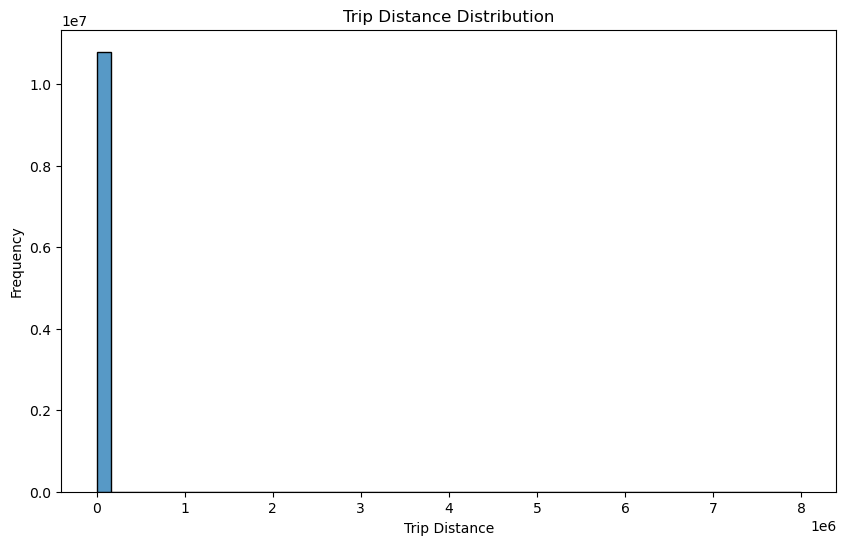

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(df['trip_distance'], bins=50)

plt.title("Trip Distance Distribution")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")

plt.show()

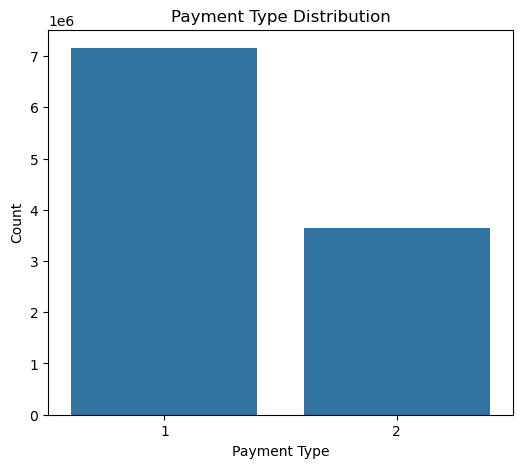

In [29]:
plt.figure(figsize=(6,5))

sns.countplot(x='payment_type', data=df)

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")

plt.show()


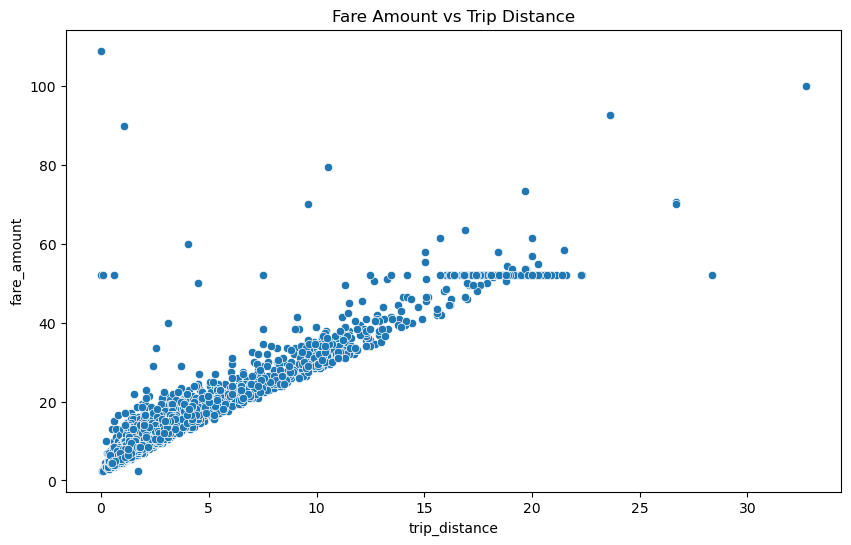

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='trip_distance',
    y='fare_amount',
    data=df.sample(5000)
)

plt.title("Fare Amount vs Trip Distance")

plt.show()


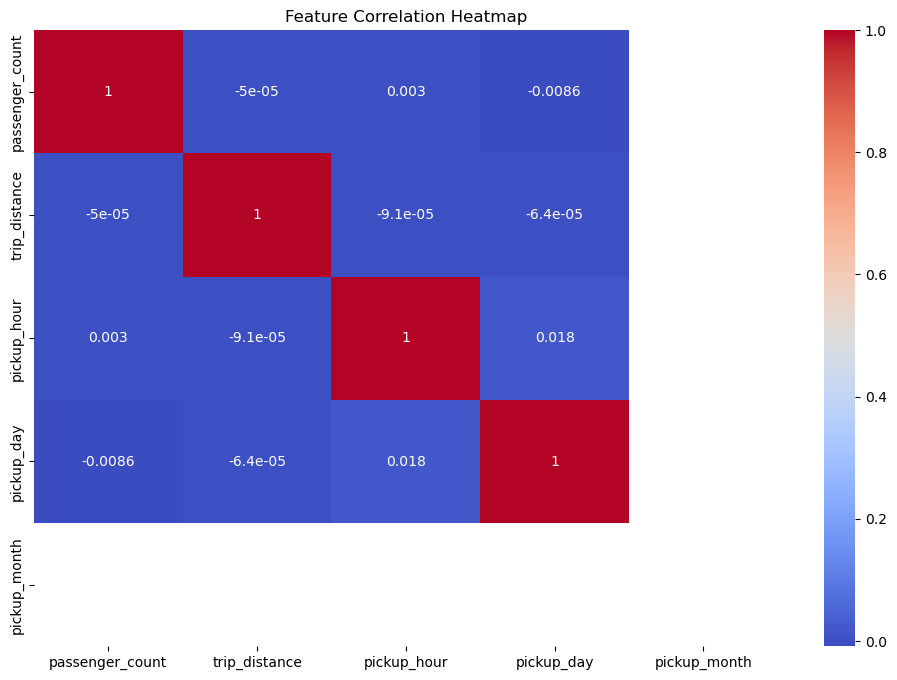

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Logistic Regression

In [32]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [33]:
lr_accuracy = accuracy_score(y_test, lr_predictions)

In [34]:
print("\nAccuracy:")
print(lr_accuracy)


Accuracy:
0.8701685648696477


In [35]:
print("\nConfusion Matrix:")

lr_cm = confusion_matrix(y_test, lr_predictions)

print(lr_cm)


Confusion Matrix:
[[1879357       1]
 [ 280404       0]]


In [36]:
print("\nClassification Report:")

print(classification_report(y_test, lr_predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93   1879358
           1       0.00      0.00      0.00    280404

    accuracy                           0.87   2159762
   macro avg       0.44      0.50      0.47   2159762
weighted avg       0.76      0.87      0.81   2159762



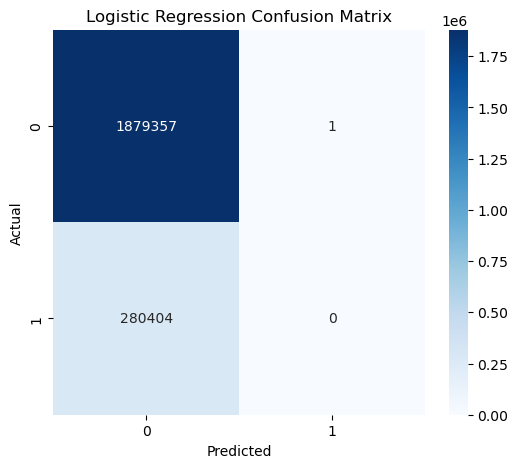

In [37]:
plt.figure(figsize=(6,5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Decision Tree

In [38]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [39]:
dt_accuracy = accuracy_score(y_test, dt_predictions)

In [40]:
print("\nAccuracy:")
print(dt_accuracy)


Accuracy:
0.9772951834507692


In [41]:
print("\nConfusion Matrix:")

dt_cm = confusion_matrix(y_test, dt_predictions)

print(dt_cm)


Confusion Matrix:
[[1864156   15202]
 [  33835  246569]]


In [42]:
print("\nClassification Report:")

print(classification_report(y_test, dt_predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99   1879358
           1       0.94      0.88      0.91    280404

    accuracy                           0.98   2159762
   macro avg       0.96      0.94      0.95   2159762
weighted avg       0.98      0.98      0.98   2159762



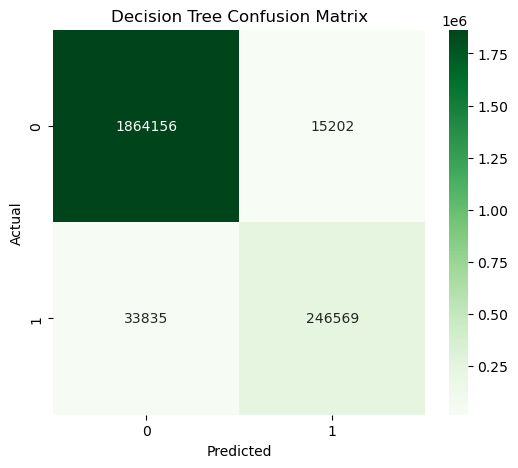

In [43]:
plt.figure(figsize=(6,5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [44]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy
    ]
})

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression  0.870169
1        Decision Tree  0.977295


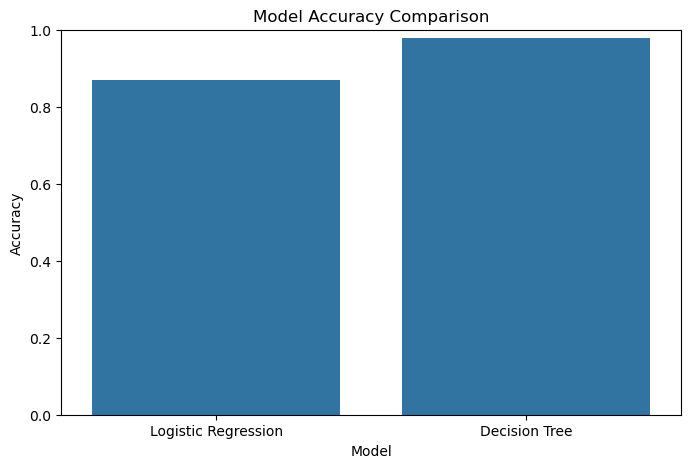

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

### Testing

In [47]:
sample_data = pd.DataFrame({
    'passenger_count': [2],
    'trip_distance': [5.5],
    'pickup_hour': [14],
    'pickup_day': [15],
    'pickup_month': [1]
})


sample_scaled = scaler.transform(sample_data)


lr_prediction = lr_model.predict(sample_scaled)

print("\nLogistic Regression Prediction:")

if lr_prediction[0] == 1:
    print("High Fare Trip (Expensive Trip)")
else:
    print("Low Fare Trip (Cheap Trip)")

dt_prediction = dt_model.predict(sample_scaled)

print("\nDecision Tree Prediction:")

if dt_prediction[0] == 1:
    print("High Fare Trip (Expensive Trip)")
else:
    print("Low Fare Trip (Cheap Trip)")


Logistic Regression Prediction:
Low Fare Trip (Cheap Trip)

Decision Tree Prediction:
High Fare Trip (Expensive Trip)
